In [1]:
%load_ext autoreload
%autoreload 2

# HCA-GPT: How to train a GPT from scratch

In this notebook we will go through the steps needed to implement a GPT from scratch and train it - to the extent possible - on a consumer laptop. We will start by parsimg a piece of text, translating it into tokens and implementing a method splitting the tokens into batches to be used during training.

Next, we will implement the building blocks of the GPT model. This includes of course the multi-head attention blocks and also feed-forward and layer normalization modules. We will combine all of these into the final GPT model.
 
The fairytale "The Nightingale" by H. C. Andersen will be used as training text. The artificial, mechanical nightingale seems a fitting analogy of the pattern recognition employed by GPTs. After training, our GPT should be able to generate text resembling mid-1800 Danish or at least fractions of the fairytale.

This notebook is roughly based on [Build A Larger Language Model (from scratch)](https://sebastianraschka.com/llms-from-scratch/) by Sebastian Raschka and I highly recommend the book.

## 1. Translate the text into tokens

GPTs do not work directly on raw text, instead the text must first be split into small chunks called tokens. The allowed tokens are predefined and given in a vocabolary of a fixed size. Since the vocabulary is fixed in size, each token is associated with an integer token id. Hence, the text is encoded into a string of intergers and can be losslessly be decoded back into the original text.

We will use the GPT2 tokenizer which is based on [Byte Pair Encoding](https://en.wikipedia.org/wiki/Byte-pair_encoding).



We read in the fairytale and see that it contains 18,136 characters:

In [2]:
with open('../text/nattergalen.txt', 'r', encoding='utf-8') as f:
    text = f.read()

print(text[:88])
print('Number of characters:', len(text))

I China veed Du jo nok er Keiseren en Chineser, og Alle de han har om sig ere Chinesere.
Number of characters: 18136


Next we instantiate the tokenizer and we see that it works on vocabulary of 50,257 unique tokens:

In [3]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")
print('Vocabulary size:', tokenizer.n_vocab)


Vocabulary size: 50257


In [61]:
def show_token(i):
    try:
        u = tokenizer.token_byte_values()[i].decode('utf-8')
    except:
        u = '?'
    print(u)

for i in range(10_000, 10_005):
    show_token(i)

print('-'*100)

for i in range(50_000, 50_005):
    show_token(i)


 Razer
 Razor
 Rd
 Re
 Reach
----------------------------------------------------------------------------------------------------
カ
ガ
キ
ギ
ク


We can see that the tokenizer is focused on English words, however, it will be able to encode any language as it will simply break down unknown words into smaller chunks untill it finds a matching token in the vocabulary.

Now let's encode our text giving us 7,621 tokens:

In [5]:
tokens = tokenizer.encode(text)
print(len(tokens))

7621


We can decode the tokens back to the original text:

In [6]:
print('Token Id | Token')
print('---------+---------')
for i in range(10):
    token_id = tokens[i]
    token = tokenizer.decode([token_id])
    print(f'{token_id:<8} | "{token}"')

print()
print(tokenizer.decode(tokens)[0:100])
    

Token Id | Token
---------+---------
40       | "I"
2807     | " China"
1569     | " ve"
276      | "ed"
10343    | " Du"
2525     | " jo"
299      | " n"
482      | "ok"
1931     | " er"
3873     | " Ke"

I China veed Du jo nok er Keiseren en Chineser, og Alle de han har om sig ere Chinesere. Det er nu m


## 2. Preparing the text for training
The [make_data_loader](github.com) function takes some text and organises it into batches of input and target tokens. Let's give it a run to see how it works:

In [71]:
from sturnus.util import make_data_loader

data_loader = make_data_loader(text, batch_size=2, length_max=4, stride=4, shuffle=False)

print('All tokens: ', tokens)

for i, (input_tokens, target_tokens) in enumerate(data_loader):
    if i > 1:
        break

    print(f'Batch {i}:')
    print('input_tokens:\n', input_tokens)
    print('target_tokens:\n', target_tokens)
    print()




All tokens:  [40, 2807, 1569, 276, 10343, 2525, 299, 482, 1931, 3873, 271, 14226, 551, 609, 1127, 263, 11, 267, 70, 978, 293, 390, 289, 272, 3971, 39030, 43237, 304, 260, 609, 1127, 567, 13, 4614, 1931, 14364, 582, 469, 317, 283, 9785, 268, 11, 1450, 655, 4587, 1640, 1931, 1062, 410, 21241, 4372, 379, 289, 24172, 260, 5590, 273, 2013, 11, 277, 24172, 81, 582, 308, 10671, 647, 2853, 0, 3873, 271, 567, 5907, 32026, 1401, 1062, 778, 21241, 13655, 328, 4169, 1312, 4643, 6559, 11, 308, 504, 365, 267, 70, 257, 335, 417, 274, 6580, 25912, 600, 20139, 5276, 391, 11, 473, 64, 479, 455, 16575, 11, 1450, 473, 64, 1341, 73, 24172, 17034, 11, 473, 64, 47930, 365, 4604, 83, 379, 374, 24172, 260, 410, 276, 11, 379, 582, 17266, 265, 660, 2760, 298, 4604, 256, 496, 43237, 1312, 363, 83, 13, 314, 21425, 473, 3609, 582, 390, 329, 4625, 4604, 4169, 1086, 296, 1706, 11, 267, 70, 410, 276, 390, 477, 263, 1050, 21241, 13655, 328, 4169, 1401, 4587, 12207, 316, 311, 24172, 6780, 41582, 482, 6122, 11, 4587, 479

We asked for a batch size of 2 with a maximum length of 4 tokens per example and that is what we got. The first batch contain an input and a target tensor both of shape (2,4). We see that the target tokens are merely shifted one place to the right compared to the input tokens. This allows us to train the model to predict the second token when only given the first and to predict the third token when given the first and second tokens as input etc.

The stride of 4 ensures that there are 4 tokens between each example. This corresponds to the maximum lenght and there is therefore no overlap between examples.

## 3. Building blocks for our GPT implementation
### 3.1 Embedding vectors

Next we will add embedding vectors. Embedding vectors are vectors with learnable values representing each token value. So for each token in our vocabulary we will have a learnable embedding vector containing continuos values. We saw above that the BPE tokenizer has a vocabulry of 50,257 possible tokens. We will set up each embedding vector to hold 256 parameters so total we will need 50257 times 256 parameters:

In [8]:
import torch

vocab_size = 50257
output_dim = 256

torch.manual_seed(42)
embedding_layer = torch.nn.Embedding(vocab_size, output_dim)
print(embedding_layer)

Embedding(50257, 256)


In [9]:
max_length = 4
data_loader = make_data_loader(
    text,
    batch_size=8,
    length_max=max_length,
    stride=max_length,
    shuffle=False
)

# inputs dim: [8, 4]
# output dim: [8, 4]

data_iter = iter(data_loader)
input_tokens, target_tokens = next(data_iter)

print(input_tokens.shape)
print(target_tokens.shape)



torch.Size([8, 4])
torch.Size([8, 4])


In [10]:
token_embeddings = embedding_layer(input_tokens)
print(token_embeddings.shape)

torch.Size([8, 4, 256])


So the token embeddings have the shape [batch_size, max_length, embedding_dim] = [8, 4, 256].

The `token_embeddings` do not contain any information on the positions of the individual tokens in the text. However, context is of course important when training a language model. So in order to include information about position, we will add positional embedding vector that is also learnable:

In [11]:
context_length = max_length
pos_embedding_layer = torch.nn.Embedding(context_length, output_dim)
pos_embeddings = pos_embedding_layer(torch.arange(context_length))
print(pos_embeddings.shape)
print(pos_embeddings)

torch.Size([4, 256])
tensor([[-0.6129,  0.4676,  0.9984,  ..., -0.2500, -0.3666, -0.7455],
        [ 0.8688, -0.0092,  0.7246,  ..., -1.0887, -0.6005, -0.0853],
        [ 0.5725,  0.6426, -0.0487,  ..., -0.7033, -0.8392,  1.6090],
        [ 0.3062,  0.4805,  0.0771,  ...,  0.6517,  1.5563, -0.3937]],
       grad_fn=<EmbeddingBackward0>)


In [12]:
input_embeddings = token_embeddings + pos_embeddings # [8, 4, 256] + [4, 256] = [8, 4, 256]
print(input_embeddings.shape)

torch.Size([8, 4, 256])


The `pos_embeddings` tensor is broadcastet along the batch dimennsion of the `token_embeddings` tensor.

### 3.2 Self-attention

Self-attention or scaled dot-product attention is at the heart of the attention block and thereby the GPT models. This is what is described in Equation 1 of the famous "[Attention is all you need](https://arxiv.org/abs/1706.03762)" paper. 
For simplicity, we start out with a simple example with an input containing six tokens each represented by a three dimensional embedding vector:

In [115]:
torch.manual_seed(42)
d_embed = 3 
inputs = torch.randn(6, d_embed)
print(inputs)


tensor([[ 1.9269,  1.4873, -0.4974],
        [ 0.4396, -0.7581,  1.0783],
        [ 0.8008,  1.6806,  0.3559],
        [-0.6866,  0.6105,  1.3347],
        [-0.2316,  0.0418, -0.2516],
        [ 0.8599, -0.3097, -0.3957]])


The first step of the attention mechsnism is to calculate *query*, *key* and *value* vectors for each input token. These are calculated using parameters that are optimizied during the training the GPT. As an example we can instantiate parameter matrices that project from the three-dimensional input embeddings to two-dimensional vectors:

In [116]:
d_out = 2

torch.manual_seed(42)
W_Q = torch.nn.Parameter(torch.randn(d_embed, d_out), requires_grad=False)
W_K = torch.nn.Parameter(torch.randn(d_embed, d_out), requires_grad=False)
W_V = torch.nn.Parameter(torch.randn(d_embed, d_out), requires_grad=False)

With these paramters instantiated, we can now calculate the query, key and value vectors. We do it at onces for all six input tokens using matrix multiplication, giving us matrices of shape 6x2:

In [121]:
keys = inputs @ W_K  # [6, 3] @ [3, 2] = [6, 2]
values = inputs @ W_V  # [6, 3] @ [3, 2] = [6, 2]
queries = inputs @ W_Q  # [6, 3] @ [3, 2] = [6, 2]

From the queries and the keys, we then calculate the attention scores:

In [124]:
attention_scores = queries @ keys.T  # [6, 2] @ [6, 2].T = [6, 6]

We then use softmax to normalize the attention scores. The factor $\sqrt{d_{key}}$ is the reason for the name *scaled* dot-product attention. When the embedding dimension is increased in size, the gradients of the attention weights can become quite small leading to inefficient training. The scaling factor is a remedy for this problem.

In [126]:
d_key = keys.shape[-1]
attention_weights = torch.softmax(attention_scores / d_key ** 0.5, dim=-1)
print(attention_weights)

tensor([[0.7450, 0.0356, 0.1783, 0.0100, 0.0039, 0.0272],
        [0.0061, 0.0895, 0.0241, 0.3018, 0.4891, 0.0894],
        [0.2011, 0.1709, 0.2168, 0.1826, 0.1067, 0.1219],
        [0.0016, 0.0625, 0.0114, 0.3591, 0.5143, 0.0511],
        [0.2539, 0.1545, 0.1945, 0.1221, 0.1163, 0.1588],
        [0.4723, 0.1058, 0.2142, 0.0525, 0.0435, 0.1117]])


Each row sums up to 1.0:

In [100]:
attention_weights.sum(dim=-1)

tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])

Finally, we can calculate the context vectors which are the result of the attention calculation:

In [103]:
context_vectors = attention_weights @ values  # [6, 6] @ [6, 2] = [6, 2]
print(context_vectors)

tensor([[0.2845, 0.4071],
        [0.2854, 0.4081],
        [0.2854, 0.4075],
        [0.2864, 0.3974],
        [0.2863, 0.3910],
        [0.2860, 0.4039]])


The final implementation of the attention calculation can be seen the model.py file. A number of things have been added:
- The algorithm has now been implemented as a PyTorch Module which makes it easy to integrate it into our final GPT model.
- We have extended it to multi-head attention meaning that instead of just one attention head, we now have multiple heads working in parallel allowing them focus on different aspects of the input string. For efficiency all attention heads share the same parameter matrices allowing matrix multiplication to be done for all heads in one go. Different slices of the matrices are then used by each head.
- A [dropout](https://www.cs.toronto.edu/~rsalakhu/papers/srivastava14a.pdf) layer has been added for regularization and to prevent over-reliance on specific paramter values.

In [132]:
from sturnus.model import MultiHeadAttention

batch = torch.stack((inputs, inputs), dim=0)  # [B, C, I] = [2, 6, 3]
print('Bath shape:', batch.shape)

mha = MultiHeadAttention(
    d_in=3,
    d_out=20,
    context_length=6,
    head_count=5,
    dropout_rate=0.4
)

context_vectors = mha(batch)  # [batch_size, token_count, d_out] = [2, 6, 20]
print('Context vectors shape:', context_vectors.shape)  

Bath shape: torch.Size([2, 6, 3])
Context vectors shape: torch.Size([2, 6, 20])


## GPT Implementation

In [135]:
GPT_CONFIG_124 = {
    'vocab_size': 50257,
    'block_size': 1024,
    'count_heads': 12,
    'count_blocks': 12,
    'embed_dim': 768,
    'dropout': 0.1,
    'qkv_bias': False,
}

### Layer Normalization

[Layer normalisation](https://arxiv.org/abs/1607.06450) normalizes the inputs across the embedding dimension. This is often used in deep neural netowrks to improve training efficiency and reduce numerical instabilities. Below we will instantiate the LayerNorm class from the [model.py](https://github.com/crs17/sturnus/blob/main/src/sturnus/model.py) file and pass the inputs through it. Since the parameters `scale` and `shift` are initiialized to 1 and 0, respectively, we see that the normalized inputs have (close to) mean 0 anv variance 1 for each example:

In [167]:
from sturnus.model import LayerNorm

print('Input mean:\n', torch.mean(inputs, dim=-1))
print('Input variance:\n', torch.var(inputs, dim=-1))

ln = LayerNorm(3)
inputs_normed = ln.forward(inputs)

print('Normalized mean:\n', torch.mean(inputs_normed, dim=-1))
print('Normalized variance:\n', torch.var(inputs_normed, dim=-1))    







Input mean:
 tensor([ 0.9723,  0.2533,  0.9458,  0.4195, -0.1471,  0.0515])
Input variance:
 tensor([1.6683, 0.8692, 0.4545, 1.0488, 0.0269, 0.4920])
Normalized mean:
 tensor([-3.9736e-08,  1.9868e-08,  1.9868e-08,  3.9736e-08,  5.9605e-08,
         1.9868e-08], grad_fn=<MeanBackward1>)
Normalized variance:
 tensor([1.0000, 1.0000, 1.0000, 1.0000, 0.9996, 1.0000],
       grad_fn=<VarBackward0>)


### Activation function
The GELU, Guassian error linear unit, activation function is often used in LLMs. It has the advantage over the traditional ReLU, Rectified Linear Unit, activation function, that it has non-zero values for negative values of x and therefore yields non-zero gradients.
The GELU activation function is given as $GELU(x) = \phi(x) \cdot x$ where $\phi(x)$ is the cumulative distribution function of the normal distribution. It turns out that it can be approximated to lessen the computational burden using: $\frac{x}{2} \cdot (1 + \tanh(\sqrt{\frac{2}{\pi}} \cdot (x + 0.044715 x^{3})$ and that is the approximation we will use.

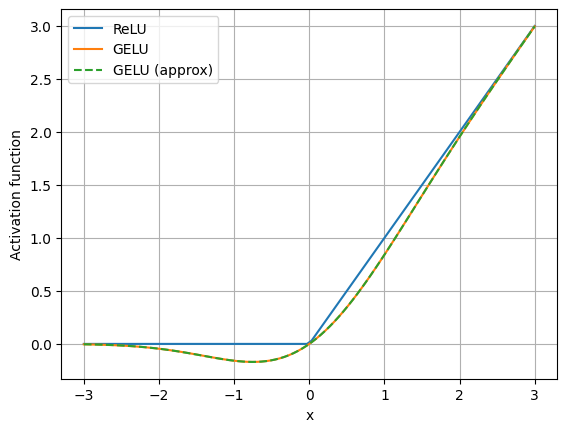

In [168]:
import matplotlib.pyplot as plt

x = torch.linspace(-3, 3, 100)
gelu = torch.nn.GELU()
gelu_approx = torch.nn.GELU(approximate='tanh')

plt.plot(x, torch.relu(x), label='ReLU')
plt.plot(x, gelu(x), label='GELU')
plt.plot(x, gelu_approx(x), '--', label='GELU (approx)')
plt.grid()
plt.xlabel('x')
plt.ylabel('Activation function')
plt.legend()
plt.show()




In [169]:
from sturnus.model import FeedForward

ffn = FeedForward(GPT_CONFIG_124)
x = torch.randn(2, 1024, 768)
y = ffn(x)
print(y.shape)




torch.Size([2, 1024, 768])


### Shortcut Connections
Shortcut connections are frequently used in deep neural networks as they gradients to travel more quickly through the layers. Below is a small example with made up training data and a neural network with 10 layers each holding 10 neurons. In the plot below we see that the training of the network with shortcut connections is typically more efficient (the loss goes down quicker) than for the network without.

In [220]:
class ShortcutExampleNN(torch.nn.Module):
    def __init__(self, count_layers: int, use_shortcut: bool):
        super().__init__()
        self.use_shortcut = use_shortcut
        self.layers = torch.nn.ModuleList(
            [
                torch.nn.Sequential(
                    torch.nn.Linear(10, 10),
                    torch.nn.GELU(approximate='tanh')
                )
                for i in range(count_layers)
            ]            
        )

    def forward(self, x: torch.tensor) -> torch.tensor:
        for layer in self.layers:
            if self.use_shortcut:
                x = x + layer(x)
            else:
                x = layer(x)
        return x
    

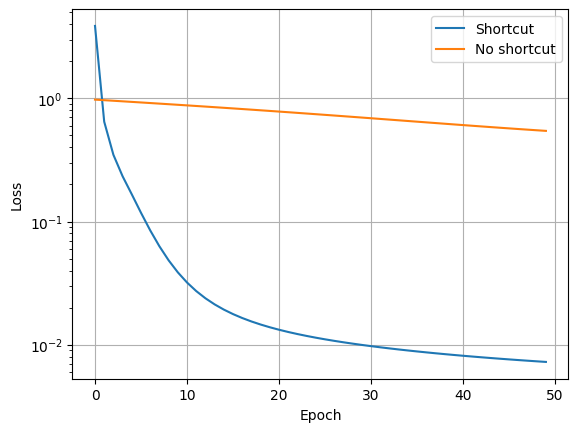

In [240]:
def train_shortcut_example(model, x, target):
    losses = []
    optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
    for i in range(50):
        y = model(x)
        loss = torch.nn.MSELoss()(y, target)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        losses.append(loss.item())
    return losses

torch.manual_seed(42)
x = torch.randn(10)
target = torch.randn(10)

losses_shortcut = train_shortcut_example(
    ShortcutExampleNN(count_layers=10, use_shortcut=True), x, target
)
losses_no_shortcut = train_shortcut_example(
    ShortcutExampleNN(count_layers=10, use_shortcut=False), x, target
)

plt.plot(losses_shortcut, label='Shortcut')
plt.plot(losses_no_shortcut, label='No shortcut')
plt.legend()
plt.yscale('log')
plt.grid()
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

### Transformer Block

In [58]:
torch.manual_seed(123)

x = torch.randn(2, 1024, 768)

transformer_block = TransformerBlock(GPT_CONFIG_124)
y = transformer_block(x)
print(x.shape)
print(y.shape)


torch.Size([2, 1024, 768])
torch.Size([2, 1024, 768])


### GPT model

In [62]:
torch.manual_seed(123)

model = GPTModel(GPT_CONFIG_124)

batch = torch.tensor(
    [[6109,  3626,  6100,   345],
     [6109,  1110,  6622,   257]]
)

y = model(batch)
print(batch.shape)
print(y.shape)
print(y)



torch.Size([2, 4])
torch.Size([2, 4, 50257])
tensor([[[ 0.3613,  0.4222, -0.0711,  ...,  0.3483,  0.4661, -0.2838],
         [-0.1792, -0.5660, -0.9485,  ...,  0.0477,  0.5181, -0.3168],
         [ 0.7120,  0.0332,  0.1085,  ...,  0.1018, -0.4327, -0.2553],
         [-1.0076,  0.3418, -0.1190,  ...,  0.7195,  0.4023,  0.0532]],

        [[-0.2564,  0.0900,  0.0335,  ...,  0.2659,  0.4454, -0.6806],
         [ 0.1230,  0.3653, -0.2074,  ...,  0.7705,  0.2710,  0.2246],
         [ 1.0558,  1.0318, -0.2800,  ...,  0.6936,  0.3205, -0.3178],
         [-0.1565,  0.3926,  0.3288,  ...,  1.2630, -0.1858,  0.0388]]],
       grad_fn=<UnsafeViewBackward0>)


In [63]:
total_parameters = sum([p.numel() for p in model.parameters()])
print(f'Total parameters: {total_parameters}')






Total parameters: 163009536


In [246]:
def generate_text_simple(model, idx, max_new_tokens, context_size):
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:, -1, :]
        probas = torch.softmax(logits, dim=-1)
        idx_next = torch.argmax(probas, dim=-1, keepdim=True)
        idx = torch.cat((idx, idx_next), dim=1)

    return idx

In [65]:
start_text = 'Hello, I am'
encoded = tokenizer.encode(start_text)
print(encoded)
encoded_tensor = torch.tensor(encoded).unsqueeze(0)
print(encoded_tensor)

model.eval()
out = generate_text_simple(
    model,
    encoded_tensor,
    max_new_tokens=6,
    context_size=GPT_CONFIG_124['block_size']
)
print(out)
decoded_text = tokenizer.decode(out.squeeze(0).tolist())
print(decoded_text)

[15496, 11, 314, 716]
tensor([[15496,    11,   314,   716]])
tensor([[15496,    11,   314,   716, 27018, 24086, 47843, 30961, 42348,  7267]])
Hello, I am Featureiman Byeswickattribute argue


## LLM Pre-training

In [242]:
GPT_CONFIG_124_local = {
    'vocab_size': 50257,
    'block_size': 256,  # 1024, This makes it possible to train on a normal laptop
    'count_heads': 12,
    'count_blocks': 12,
    'embed_dim': 768,
    'dropout': 0.1,
    'qkv_bias': False,
}

In [243]:
import torch

from sturnus.model import GPTModel

torch.manual_seed(42)

model = GPTModel(GPT_CONFIG_124_local)
# model.eval?


In [244]:
sum([p.numel() for p in model.parameters()])

162419712

In [247]:
def text_to_tokens(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={"<|endoftext|>"})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0)
    return encoded_tensor

def tokens_to_text(tokens, tokenizer):
    return tokenizer.decode(tokens.squeeze(0).tolist())

start_text = 'Every effort moves you'
tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model=model,
    idx=text_to_tokens(start_text, tokenizer),
    max_new_tokens=10,
    context_size=GPT_CONFIG_124_local['block_size']
)
print('Ouput text:', tokens_to_text(token_ids, tokenizer))




Ouput text: Every effort moves youodonicle ' directly inflamm honeyopoly Kw ply benefit


### Small example

In [248]:
# inputs = torch.tensor([[16833, 3626, 6100],   # ["every effort moves",
#                        [40,    1107, 588]])   #  "I really like"]

# targets = torch.tensor([[3626, 6100, 345  ],  # [" effort moves you",
#                         [1107, 588, 11311]])  #  " really like chocolate"]

In [249]:
# with torch.no_grad():     #1
#     logits = model(inputs)
# probas = torch.softmax(logits, dim=-1)     #2
# print(probas.shape)

In [250]:
# token_ids = torch.argmax(probas, dim=-1, keepdim=True)
# print("Token IDs:\n", token_ids)  


In [251]:
# text_idx = 0
# target_probas_1 = probas[text_idx, [0, 1, 2], targets[text_idx]]
# print("Text 1:", target_probas_1)

# text_idx = 1
# target_probas_2 = probas[text_idx, [0, 1, 2], targets[text_idx]]
# print("Text 2:", target_probas_2)

In [253]:
# log_probas = torch.log(torch.cat((target_probas_1, target_probas_2)))
# print(log_probas)

In [254]:
# avg_log_probas = torch.mean(log_probas)
# print(avg_log_probas)

In [256]:
# targets.shape

In [257]:
# logits_flat = logits.flatten(0, 1)
# targets_flat = targets.flatten()

# loss = torch.nn.functional.cross_entropy(logits_flat, targets_flat)
# print(loss)






In [258]:
# loss.item?

In [259]:
# perplexity = torch.exp(loss)
# print(perplexity)

In [262]:
total_characters = len(text)
total_tokens = len(tokenizer.encode(text))
print(f'Total characters: {total_characters}')
print(f'Total tokens: {total_tokens}')

Total characters: 18136
Total tokens: 7621


In [263]:
### text = text_the_verdict

train_ratio = 0.9
split_idx = int(train_ratio * total_characters)
train_text = text[:split_idx]
val_text = text[split_idx:]
print(f'Train text length: {len(train_text)}')
print(f'Validation text length: {len(val_text)}')




Train text length: 16322
Validation text length: 1814


In [264]:
torch.manual_seed(123)

train_loader = make_data_loader(
    train_text,
    batch_size=2,
    length_max=GPT_CONFIG_124_local['block_size'],
    stride=GPT_CONFIG_124_local['block_size'],
    shuffle=True,
    drop_last=True,
    worker_count=0
)

val_loader = make_data_loader(
    val_text,
    batch_size=2,
    length_max=GPT_CONFIG_124_local['block_size'],
    stride=GPT_CONFIG_124_local['block_size'],
    shuffle=True,
    drop_last=True,
    worker_count=0
)

In [265]:
print("Train loader:")
for x, y in train_loader:
    print(x.shape, y.shape)

print("\nValidation loader:")
for x, y in val_loader:
    print(x.shape, y.shape)

Train loader:
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])

Validation loader:
torch.Size([2, 256]) torch.Size([2, 256])


In [266]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch = input_batch.to(device)
    target_batch = target_batch.to(device)
    logits = model(input_batch)
    logits_flat = logits.flatten(0, 1)
    targets_flat = target_batch.flatten()
    loss = torch.nn.functional.cross_entropy(logits_flat, targets_flat)
    return loss


def calc_loss_loader(dataloader, model, device, batch_count=None):
    total_loss = 0
    if len(dataloader) == 0:
        return float('nan')

    if batch_count is None:
        batch_count = len(dataloader)
    else:
        batch_count = min(batch_count, len(dataloader))

    for i, (input_batch, target_batch) in enumerate(dataloader):
        if i >= batch_count:
            break
        total_loss += calc_loss_batch(input_batch, target_batch, model, device).item()

    return total_loss / batch_count



In [267]:
torch.backends.mps.is_available()

True

In [268]:
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
model.to(device)

with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device)
    val_loss = calc_loss_loader(val_loader, model, device)

print(f'Train loss: {train_loss}')
print(f'Validation loss: {val_loss}')






Train loss: 11.006758103003868
Validation loss: 11.032201766967773


In [269]:
device

device(type='mps')

In [270]:
torch.cuda.is_available()

False

In [301]:
def train_model_simple(
    model,
    train_loader,
    val_loader,
    optimizer,
    device,
    num_epochs,
    eval_freq,
    eval_iter,
    start_context,
    tokenizer
):
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1

    for epoch in range(num_epochs):
        model.train()
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()
            loss = calc_loss_batch(
                input_batch, target_batch, model, device
            )
            loss.backward()
            optimizer.step()
            tokens_seen += input_batch.numel()
            global_step += 1

            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter
                )
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(
                    f"Ep {epoch+1} (Step {global_step:06d}): "
                    f"Train loss {train_loss:.3f}, "
                    f"Val loss {val_loss:.3f}"
                )
        generate_and_print_sample(
            model, tokenizer, device, start_context
        )
    
    return train_losses, val_losses, track_tokens_seen






In [291]:
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, batch_count=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, batch_count=eval_iter)
    model.train()
    return train_loss, val_loss


In [292]:
def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_tokens(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text_simple(
            model=model, idx=encoded, max_new_tokens=50, context_size=context_size
        )
    decoded_text = tokens_to_text(token_ids, tokenizer)
    print(decoded_text.replace('\n', ' '))
    model.train()



In [293]:
GPT_CONFIG_124_local

{'vocab_size': 50257,
 'block_size': 256,
 'count_heads': 12,
 'count_blocks': 12,
 'embed_dim': 768,
 'dropout': 0.1,
 'qkv_bias': False}

In [ ]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124_local)
model.to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.0004,
    weight_decay=0.1
)
num_epochs = 10
train_losses, val_losses, tokens_seen = train_model_simple(
    model,
    train_loader,
    val_loader,
    optimizer,
    device,
    num_epochs,
    eval_freq=10,
    eval_iter=5,
    start_context='Keiserens største ønske er',
    tokenizer=tokenizer
)

Ep 1 (Step 000000): Train loss 9.724, Val loss 9.926
Ep 1 (Step 000010): Train loss 5.373, Val loss 6.177
Keiserens største ønske er, ogø, og det, og, og, og det, og det, og hø, og hø, ogø, og, og det, og hø, o
Ep 2 (Step 000020): Train loss 4.054, Val loss 5.035
Keiserens største ønske er kom den lille, men saa stille, men saa stille, men saa gikkelige, men saa en Nattergalen, men saa var saa   “jøre
Ep 3 (Step 000030): Train loss 2.891, Val loss 4.715
Keiserens største ønske er det er det er ligesom om Nattergalen, og een, og noget, og løre Gange, og saa stod der var der skulde han, og sa
Ep 4 (Step 000040): Train loss 2.559, Val loss 4.569
Ep 4 (Step 000050): Train loss 1.657, Val loss 4.546
Keiserens største ønske er kom man i den, og deiligt, og de deiligt i Øinene.      “Det er dog det var den!” sagde deiligt!
Ep 5 (Step 000060): Train loss 1.403, Val loss 4.745
Keiserens største ønske er ligesom om Nattergal!” sagde Keiseren, og der sad noget paa høre Nattergalen gik, forunderli

In [309]:
print(tokens_seen)
train_loader.dataset.input_tokens.shape
25*256

[512, 5632, 10752, 15872, 20992, 26112, 31232, 36352, 41472, 46592, 51712, 56832, 61952]


6400

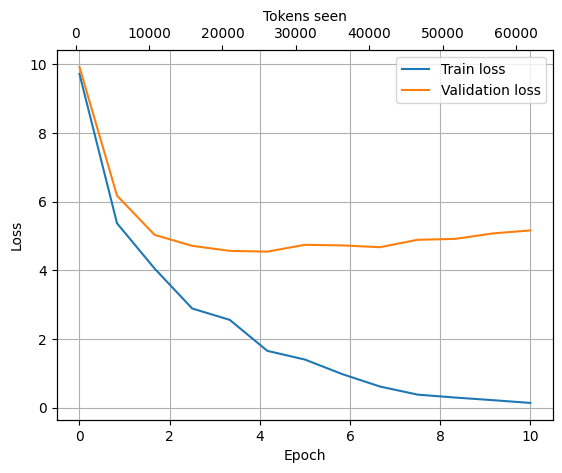

In [313]:
fig, ax = plt.subplots()
epochs_seen = torch.linspace(0, num_epochs, len(train_losses))
ax.plot(epochs_seen, train_losses, label='Train loss')
ax.plot(epochs_seen, val_losses, label='Validation loss')
ax2 =  ax.twiny()
ax2.plot(tokens_seen, train_losses, alpha=0)
ax.legend()
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax2.set_xlabel('Tokens seen')
# ax.set_yscale('log')
ax.grid()
plt.show()




In [101]:
train_text[train_text.find('Saa begyndte'):]

'Saa begyndte Nattergalen at synge.\n\n“Den er det,” sagde den lille Pige, “hør! hør! og der sidder den!” og saa pegede hun paa en lille, graa Fugl oppe i Grenene.\n\n“Er det muligt!” sagde Cavaleren, “saaledes havde jeg nu aldrig tænkt mig den! hvor den seer simpel ud! den har vist mistet Couleur over at see saa mange fornemme Mennesker hos sig!”\n\n“Lille Nattergal!” raabte den lille Kokkepige ganske høit, “vor naadige Keiser vil saa gjerne, at De skal synge for ham!”\n\n“Med største Fornøielse!” sagde Nattergalen og sang, saa at det var en Lyst.\n\n“Det er ligesom Glasklokker!” sagde Cavaleren, “og see den lille Strube, hvor den bruger sig! det er mærkværdigt vi aldrig har hørt den før! den vil gjøre en stor succÅs ved Hoffet!”\n\n“Skal jeg synge endnu engang for Keiseren?” spurgte Nattergalen, der troede at Keiseren var med.\n\n“Min fortræffelige lille Nattergal!” sagde Cavaleren, “jeg har den store Glæde at skulle tilsige Dem til en Hoffest i Aften, hvor De vil fortrylle han høie 

In [102]:
val_text[val_text.find('Saa begyndte'):]

'”'

In [ ]:
tokens_seen


[512,
 3072,
 5632,
 8192,
 10752,
 13312,
 15872,
 18432,
 20992,
 23552,
 26112,
 28672,
 31232,
 33792,
 36352,
 38912]

In [278]:
# put on the CPU and put it in eval mode
model.to('cpu')
model.eval()


GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_Q): Linear(in_features=768, out_features=768, bias=False)
        (W_K): Linear(in_features=768, out_features=768, bias=False)
        (W_V): Linear(in_features=768, out_features=768, bias=False)
        (out_projection): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ln1): LayerNorm()
      (ffn): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='tanh')
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (ln2): LayerNorm()
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_Q): Linear(in_feature

In [284]:
start_context = 'Saa begyndte'
device = torch.device('cpu')

generate_and_print_sample(model, tokenizer, device, start_context)

Saa begyndte Fugl!” sagde Cavaleren, men han paa min Moder kyssede mig!”  “Lille Kokkepige!” sagde Cavaleren, “jeg skal skaffe


In [ ]:
def generate(model, tokenizer, device, start_context):
